# Projet de Scoring Crédit  
## Analyse exploratoire des données (EDA)

**Auteur : Laveus Mick-Wanderly**  
**Formation : Master Mathématiques & Informatique – orientation Data**  
**Objectif : Évaluation du risque de défaut de paiement**

<img src="../reports/p43.jpg" style="width:100%; border-radius:12px;">



Lorsqu’une **banque** prête de l’argent à une personne, elle prend le risque que cette dernière ne rembourse pas le montant emprunté dans le **délai convenu**. Ce risque est appelé **risque de crédit**. Avant d’octroyer un crédit, les banques vérifient si le client ou la cliente qui en fait la demande sera **capable de rembourser** le prêt.

Cette évaluation repose sur l’analyse de plusieurs **paramètres financiers et socio-économiques**, tels que les **revenus**, les **biens**, les **dépenses actuelles** ou encore la **situation professionnelle** du client. Dans de nombreuses banques, cette analyse est encore réalisée **manuellement**, ce qui la rend **très consommatrice en temps** et en **ressources financières**.

Grâce au **machine learning**, il est désormais possible d’**automatiser cette tâche** et de **prédire avec une meilleure précision** les clients susceptibles d’être en **défaut de paiement**.

Dans ce projet, nous allons construire un **algorithme de scoring crédit** capable de prédire si une personne sera en **défaut de paiement** ou non (**1 : défaut**, **0 : non-défaut**). Il s’agit donc d’un **problème de classification**, puisque l’objectif est de prédire une **variable discrète binaire**.


## Importation des bibliothèques et des données


In [30]:
# Importation du module sys pour vérifier l’interpréteur Python utilisé
import sys

# Affiche le chemin de l’exécutable Python afin de s’assurer que l’environnement virtuel du projet est bien utilisé
sys.executable


'/home/dev/projects/credit-scoring/.venv/bin/python'

In [31]:
# Importation de la bibliothèque pandas pour la manipulation et l’analyse des données
import pandas as pd

En ce qui concerne les **données**, il s’agit d’informations collectées sur d’**anciens clients** ayant contracté des **prêts**, et qui sont utilisées afin de **prédire le comportement des nouveaux clients**.

Deux (**02**) grands types de données peuvent être utilisés pour **modéliser la probabilité de défaut de paiement** :

- **Données liées à la demande de crédit** : informations fournies par le client au moment de la demande, telles que les **revenus**, la **situation professionnelle**, le **montant du crédit** ou la **durée du prêt**.
- **Données comportementales** décrivant le **bénéficiaire du prêt** : informations reflétant le **comportement passé du client**, comme l’**historique de remboursement**, la **gestion des comptes** ou les **antécédents de crédit**.

Dans la **pratique bancaire**, les établissements financiers utilisent généralement un **mélange de ces deux types de données** afin de construire leur **modèle de scoring crédit**, appliqué à la **gestion du risque de crédit**.


In [32]:
#Importation des données 

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "status_account", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status_sex",
    "other_debtors", "residence_since", "property", "age",
    "other_installment_plans", "housing", "existing_credits",
    "job", "num_dependents", "own_telephone", "foreign_worker", "target"
]

df = pd.read_csv(url, sep=" ", names=columns)
df.head()



,status_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [33]:

df.columns

Index(['status_account', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings', 'employment', 'installment_rate',
       'personal_status_sex', 'other_debtors', 'residence_since', 'property',
       'age', 'other_installment_plans', 'housing', 'existing_credits', 'job',
       'num_dependents', 'own_telephone', 'foreign_worker', 'target'],
      dtype='object')

Les données utilisées dans ce projet proviennent du jeu de données **German Credit**, largement utilisé dans la littérature en **scoring crédit** et en **apprentissage automatique**. Ce jeu de données regroupe des informations collectées sur d’anciens clients ayant contracté un **crédit bancaire**.

L’ensemble des données est composé de **21 variables** et de **1 000 observations** historiques. Chaque observation correspond à une **personne ayant contracté un prêt**. Certaines variables décrivent les **caractéristiques du crédit** (montant, durée, type de prêt, etc.), tandis que d’autres décrivent les **caractéristiques personnelles et financières du client** (âge, situation professionnelle, historique de crédit, etc.).

Ces **données historiques** sont utilisées afin de construire un **modèle de scoring crédit**, dont l’objectif est de **prédire le risque de défaut de paiement** des nouveaux candidats à un crédit. Il est donc essentiel de bien **comprendre les variables** constituant ce jeu de données avant toute étape de modélisation.


Les variables du jeu de données sont décrites ci-dessous :

- **status_account** : statut du compte bancaire du client (niveau de solde et ancienneté)
- **duration** : durée du crédit (en mois)
- **credit_history** : historique de crédit du client (comportement de remboursement passé)
- **purpose** : objectif du crédit (achat de biens, voiture, équipements, etc.)
- **credit_amount** : montant total du crédit accordé
- **savings** : niveau d’épargne du client
- **employment** : ancienneté professionnelle du client
- **installment_rate** : taux des mensualités par rapport au revenu
- **personal_status_sex** : situation personnelle et sexe du client
- **other_debtors** : présence d’autres débiteurs ou garants
- **residence_since** : durée de résidence à l’adresse actuelle
- **property** : type de biens possédés par le client
- **age** : âge du client
- **other_installment_plans** : existence d’autres plans de remboursement
- **housing** : situation de logement (locataire, propriétaire, etc.)
- **existing_credits** : nombre de crédits existants au moment de la demande
- **job** : type d’emploi occupé par le client
- **num_dependents** : nombre de personnes à charge
- **own_telephone** : possession d’un téléphone
- **foreign_worker** : statut de travailleur étranger
- **target** : variable cible indiquant si le client est en **défaut de paiement** (1) ou non (0)

Passons à l'analyse exploratoire des données qui nous permettra de mieux les comprendre.

## Analyse exploratoire et des données

In [34]:
# Résumé statistique des variables numériques du jeu de données
df.describe()


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


**Légende du résumé statistique :**  
- **count** : nombre d’observations disponibles pour chaque variable  
- **mean** : valeur moyenne  
- **std** : écart-type, mesurant la dispersion des données autour de la moyenne  
- **min** : valeur minimale observée  
- **25 % / 50 % / 75 %** : quartiles de la distribution (la valeur à **50 %** correspond à la **médiane**)  
- **max** : valeur maximale observée


### Interprétation du résumé statistique

Le jeu de données contient **1 000 observations**, ce qui correspond à **1 000 clients** ayant contracté un crédit. Aucune valeur manquante n’est observée pour les variables numériques analysées.

La **durée moyenne du crédit** est d’environ **21 mois**, avec une médiane de **18 mois**, ce qui indique que la majorité des prêts sont de **court à moyen terme**, bien que certains crédits puissent aller jusqu’à **72 mois**.

Le **montant moyen du crédit** s’élève à environ **3 271 unités monétaires**, avec une forte **dispersion** (écart-type élevé). Les montants varient fortement, allant de **250** à plus de **18 000**, ce qui traduit une **hétérogénéité importante des profils de crédit**.

Le **taux des mensualités** par rapport au revenu (`installment_rate`) est compris entre **1 et 4**, avec une médiane de **3**, suggérant que la majorité des clients supporte une charge de remboursement modérée à élevée.

L’**âge moyen des clients** est d’environ **36 ans**, avec une médiane de **33 ans**. La population étudiée est donc principalement composée d’**adultes actifs**, bien que certains clients puissent être relativement jeunes ou proches de l’âge de la retraite.

Le nombre de **crédits existants** est en moyenne de **1 à 2**, ce qui indique que la plupart des clients ne sont pas fortement endettés au moment de la demande de crédit. De même, la majorité des clients possède **une seule personne à charge**.

Enfin, la variable cible `target` montre que la majorité des clients appartient à la classe **sans défaut de paiement**, tandis qu’une proportion plus faible correspond aux clients en **défaut**, ce qui suggère un **déséquilibre modéré des classes**, caractéristique des problèmes de **scoring crédit**.


In [35]:
df.isnull().sum()


status_account             0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings                    0
employment                 0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
num_dependents             0
own_telephone              0
foreign_worker             0
target                     0
dtype: int64

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment               1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

L’analyse des données montre qu’aucune variable ne contient de **valeurs manquantes**, comme le confirme la méthode `df.isnull().sum()`. L’ensemble des colonnes comporte **1 000 observations**, indiquant un **jeu de données complet**. La commande `df.info()` confirme cette observation et met en évidence une **structure cohérente** du jeu de données, composée de variables **numériques** et **catégorielles** correctement définies. Aucun traitement spécifique lié aux valeurs manquantes n’est donc nécessaire avant la phase de modélisation.

Par ailleurs, l’examen des **statistiques descriptives** ne révèle pas de **valeurs aberrantes évidentes**. Les plages de valeurs observées pour l’**âge**, la **durée du crédit**, le **montant du prêt** et les autres variables sont cohérentes avec un **contexte bancaire réel**. Certaines variables, notamment le **montant du crédit**, présentent toutefois une **forte dispersion**, traduisant une **hétérogénéité des profils clients**, qui devra être prise en compte lors de la **modélisation**.


Passons à l'analyse de la variable cible target.

In [8]:
df["target"].value_counts()


target
1    700
2    300
Name: count, dtype: int64

In [9]:
df["target"].value_counts(normalize=True) * 100


target
1    70.0
2    30.0
Name: proportion, dtype: float64

In [7]:
#Transformer la variable cible pour la modélisation

df["target"] = df["target"].map({1:0 , 2 : 1}) 
df["target"].value_counts(normalize=True)

target
0    0.7
1    0.3
Name: proportion, dtype: float64

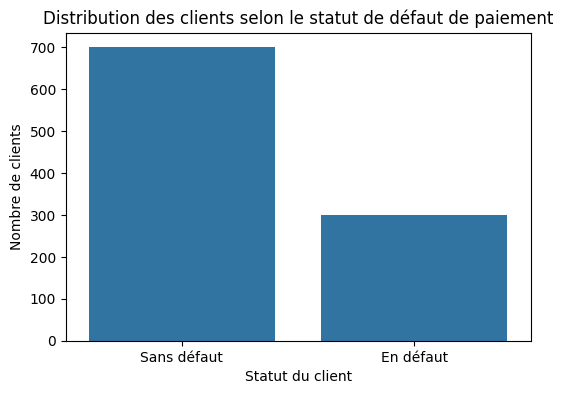

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)

plt.title("Distribution des clients selon le statut de défaut de paiement")
plt.xlabel("Statut du client")
plt.ylabel("Nombre de clients")
plt.xticks([0, 1], ["Sans défaut", "En défaut"])

plt.show()


L’analyse de la **variable cible** montre que le jeu de données contient **700 clients sans défaut de paiement** et **300 clients en défaut**, soit environ **70 % de bons clients** contre **30 % de clients en défaut**. Cette distribution met en évidence un **déséquilibre modéré des classes**, caractéristique des problématiques de **scoring crédit**, qui devra être pris en compte lors de la **modélisation**.

Le **déséquilibre de classes** est fréquemment observé dans les **données de crédit**. En effet, la majorité des **demandeurs de crédit** sont incités à ne pas être en **défaut de paiement**, car un **remboursement régulier et dans les délais** permet d’améliorer leur **cote de crédit**. Une cote de crédit élevée facilite ensuite l’accès à de **nouveaux crédits**, notamment pour financer d’**autres investissements**.

Bien que le déséquilibre observé dans ce jeu de données soit **tout à fait normal**, il n’en demeure pas moins qu’il représente un **défi majeur de classification** pour les **algorithmes de machine learning**. Lors de la phase de **préparation des données pour la modélisation**, il sera donc nécessaire de **prendre en compte ce déséquilibre** afin d’obtenir un modèle de scoring performant et fiable.



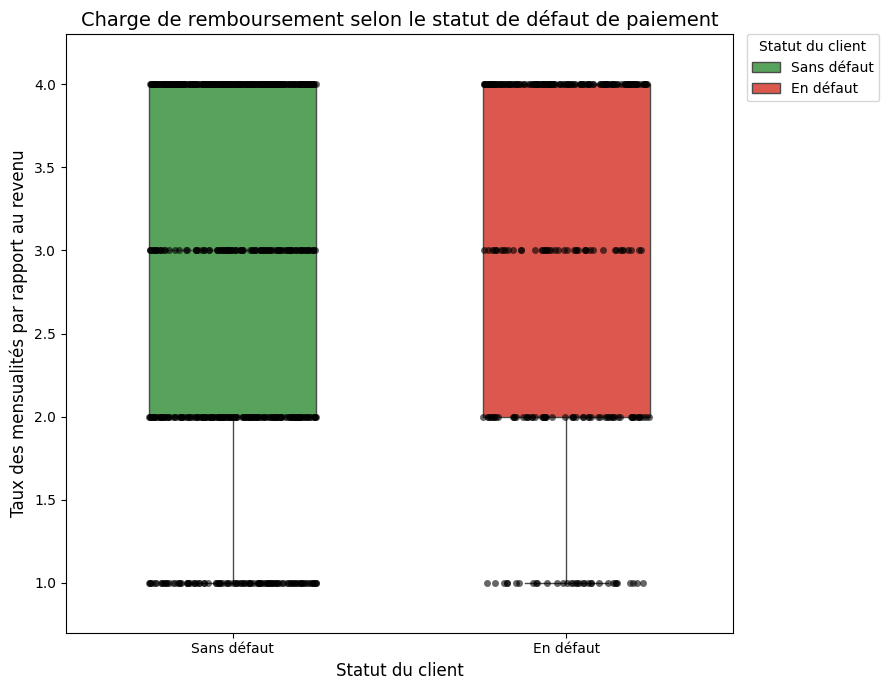

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agrandir fortement la figure
plt.figure(figsize=(9,7))

# Boxplot
sns.boxplot(
    x="target",
    y="installment_rate",
    hue="target",
    data=df,
    palette=["#4CAF50", "#F44336"],  # vert / rouge
    width=0.5,
    showfliers=True,
    dodge=False
)

# Points (plus visibles)
sns.stripplot(
    x="target",
    y="installment_rate",
    data=df,
    color="black",
    size=5,        # points plus gros
    alpha=0.6,     # plus contrastés
    jitter=0.25
)

# Titres et labels
plt.title("Charge de remboursement selon le statut de défaut de paiement", fontsize=14)
plt.xlabel("Statut du client", fontsize=12)
plt.ylabel("Taux des mensualités par rapport au revenu", fontsize=12)
plt.xticks([0, 1], ["Sans défaut", "En défaut"])

# Ajustement axe Y (voir toute la boîte)
plt.ylim(
    df["installment_rate"].min() - 0.3,
    df["installment_rate"].max() + 0.3
)

# Légende déplacée hors du graphique (droite)
plt.legend(
    title="Statut du client",
    labels=["Sans défaut", "En défaut"],
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout()
plt.show()


Le boxplot ci-dessus illustre la distribution du **taux des mensualités par rapport au revenu** selon le **statut de défaut de paiement**. La taille accrue du graphique et l’ajout de points permettent de visualiser clairement la **dispersion des observations** ainsi que les **valeurs extrêmes**. Ce graphique représente en ordonnée le taux des mensualités par rapport au revenu, utilisé comme un **indicateur de la charge de remboursement** supportée par les clients.

L’analyse met en évidence des **différences de charge de remboursement** entre les clients en défaut et ceux sans défaut. On observe que les clients en **défaut de paiement** présentent, en moyenne, des **niveaux de charge de remboursement plus élevés** que les clients sans défaut. Cela suggère que plus la part du revenu consacrée au remboursement du crédit est importante, plus le **risque de défaut** augmente, les clients disposant alors de **moins de marge financière** pour faire face à leurs autres dépenses.


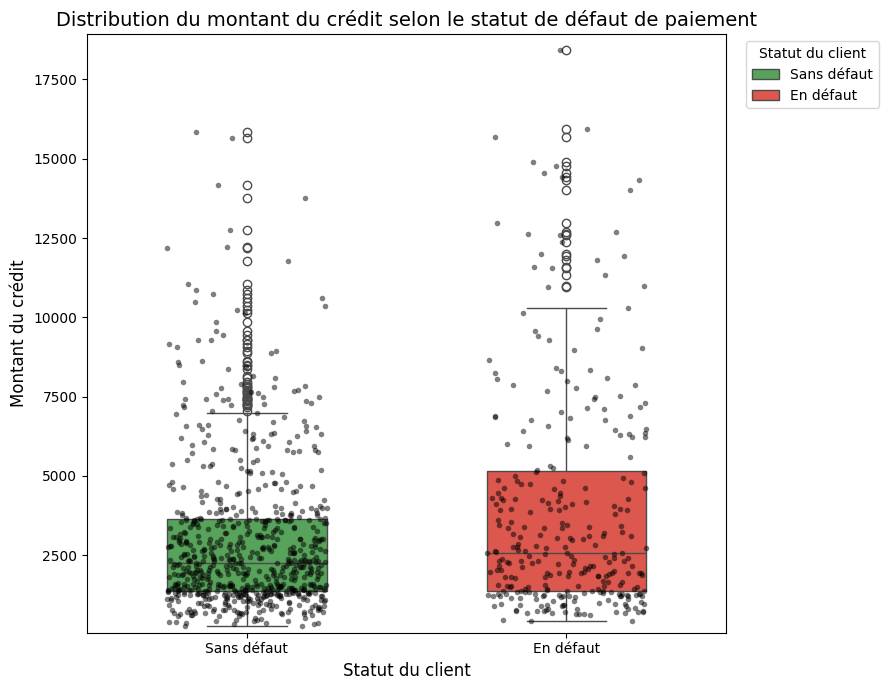

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))

# Boxplot
sns.boxplot(
    x="target",
    y="credit_amount",
    hue="target",
    data=df,
    palette=["#4CAF50", "#F44336"],  # vert = sans défaut, rouge = défaut
    width=0.5,
    showfliers=True,
    dodge=False
)

# Points (observations)
sns.stripplot(
    x="target",
    y="credit_amount",
    data=df,
    color="black",
    size=4,
    alpha=0.5,
    jitter=0.25
)

# Titres et labels
plt.title("Distribution du montant du crédit selon le statut de défaut de paiement", fontsize=14)
plt.xlabel("Statut du client", fontsize=12)
plt.ylabel("Montant du crédit", fontsize=12)
plt.xticks([0, 1], ["Sans défaut", "En défaut"])

# Ajustement axe Y pour voir les extrêmes
plt.ylim(
    df["credit_amount"].min() - 200,
    df["credit_amount"].max() + 500
)

# Légende hors graphique
plt.legend(
    title="Statut du client",
    labels=["Sans défaut", "En défaut"],
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()


Le boxplot permet de comparer la distribution de la variable étudiée entre les clients sans défaut et ceux en défaut de paiement. L’analyse met en évidence des différences notables en termes de **médiane**, de **dispersion** et de **valeurs extrêmes** entre les deux groupes.

Les clients sans défaut présentent généralement une distribution plus **concentrée**, avec une **variabilité plus faible**, traduisant des comportements plus homogènes et maîtrisés. La majorité des observations se situe entre le minimum et le premier quartile, suggérant une tendance à des niveaux plus modérés de la variable analysée.

À l’inverse, les clients en défaut montrent une distribution plus **dispersée**, avec des **valeurs plus élevées** et des **outliers plus fréquents**, indiquant une exposition accrue au risque. La présence de valeurs extrêmes plus importantes chez ces clients suggère que la variable étudiée peut constituer un **facteur discriminant du risque de défaut**, bien qu’elle ne suffise pas à elle seule pour expliquer le comportement de remboursement.

Dans l’ensemble, le boxplot met en évidence des **différences structurelles** entre les profils des clients en défaut et ceux sans défaut, soulignant l’intérêt de cette variable dans la modélisation du risque de crédit.


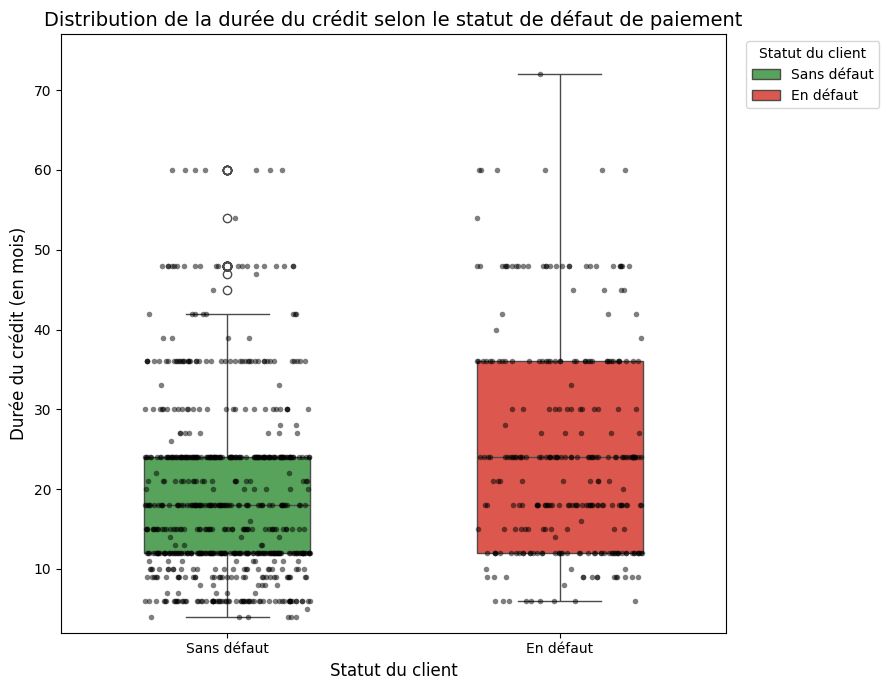

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agrandir la figure pour une meilleure lisibilité
plt.figure(figsize=(9,7))

# Boxplot
sns.boxplot(
    x="target",
    y="duration",
    hue="target",
    data=df,
    palette=["#4CAF50", "#F44336"],  # vert = sans défaut, rouge = défaut
    width=0.5,
    showfliers=True,
    dodge=False
)

# Points (observations individuelles)
sns.stripplot(
    x="target",
    y="duration",
    data=df,
    color="black",
    size=4,
    alpha=0.5,
    jitter=0.25
)

# Titres et labels
plt.title("Distribution de la durée du crédit selon le statut de défaut de paiement", fontsize=14)
plt.xlabel("Statut du client", fontsize=12)
plt.ylabel("Durée du crédit (en mois)", fontsize=12)
plt.xticks([0, 1], ["Sans défaut", "En défaut"])

# Ajustement de l’axe Y pour bien voir les extrêmes
plt.ylim(
    df["duration"].min() - 2,
    df["duration"].max() + 5
)

# Légende déplacée hors du graphique
plt.legend(
    title="Statut du client",
    labels=["Sans défaut", "En défaut"],
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()


L’analyse du boxplot de la **durée du crédit (`duration`)** met en évidence des différences notables entre les clients sans défaut et les clients en défaut de paiement.

Pour les **clients sans défaut**, on observe une forte concentration des observations entre le **minimum et le premier quartile (Q1)**, avec une proportion importante de clients ayant des durées de crédit proches de la valeur minimale. Une grande quantité d’observations se situe également entre le **premier quartile et la médiane**, puis entre la **médiane et le troisième quartile (Q3)**, traduisant une répartition relativement homogène des durées. On note par ailleurs la présence de plusieurs observations entre le **troisième quartile et la valeur maximale**, ainsi que quelques **valeurs extrêmes** au-delà du maximum, correspondant à des durées de crédit plus longues mais relativement rares. Globalement, la distribution des durées chez les clients sans défaut apparaît **plus concentrée**, avec une **variabilité plus faible**.

À l’inverse, pour les **clients en défaut**, on observe moins d’observations entre le **minimum et le premier quartile**, tandis que la **plus grande concentration de points se situe entre le premier quartile et la médiane**, avec de nombreux clients ayant des durées proches de ces valeurs. Une part importante des observations se trouve également entre la **médiane et le troisième quartile**, avec une concentration notable autour de la médiane et du troisième quartile. On observe enfin plusieurs observations entre le **troisième quartile et la valeur maximale**, mais **aucune valeur extrême au-delà du maximum**.

La comparaison des deux distributions montre que le **boxplot des clients en défaut est plus étendu** que celui des clients sans défaut, traduisant une **plus grande dispersion des durées de crédit**. Chez les clients en défaut, la médiane est plus élevée et les durées s’étendent sur un intervalle plus large, indiquant une exposition au risque plus longue dans le temps. Ces observations suggèrent que la **durée du crédit** constitue un facteur important dans l’évaluation du **risque de défaut**, les crédits de plus longue durée étant associés à une probabilité accrue de difficultés de remboursement.


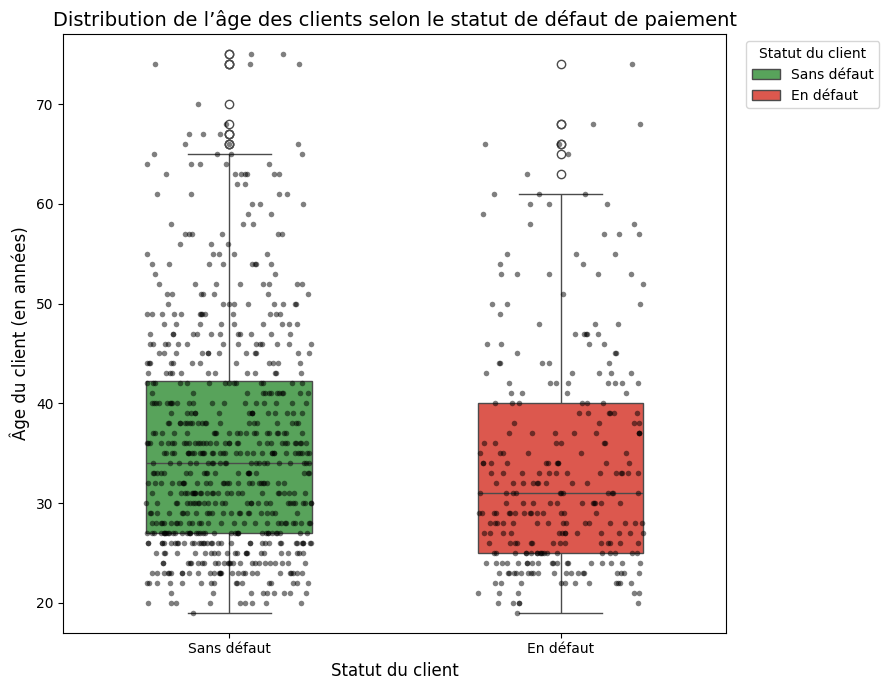

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Taille du graphique pour une bonne lisibilité
plt.figure(figsize=(9,7))

# Boxplot
sns.boxplot(
    x="target",
    y="age",
    hue="target",
    data=df,
    palette=["#4CAF50", "#F44336"],  # vert = sans défaut, rouge = défaut
    width=0.5,
    showfliers=True,
    dodge=False
)

# Points (observations individuelles)
sns.stripplot(
    x="target",
    y="age",
    data=df,
    color="black",
    size=4,
    alpha=0.5,
    jitter=0.25
)

# Titres et labels
plt.title("Distribution de l’âge des clients selon le statut de défaut de paiement", fontsize=14)
plt.xlabel("Statut du client", fontsize=12)
plt.ylabel("Âge du client (en années)", fontsize=12)
plt.xticks([0, 1], ["Sans défaut", "En défaut"])

# Ajustement de l’axe Y pour bien voir les extrêmes
plt.ylim(
    df["age"].min() - 2,
    df["age"].max() + 2
)

# Légende déplacée hors du graphique
plt.legend(
    title="Statut du client",
    labels=["Sans défaut", "En défaut"],
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()


L’analyse du boxplot de l’**âge des clients** met en évidence des différences de distribution entre les clients sans défaut et les clients en défaut de paiement.

Pour les **clients sans défaut**, le boxplot présente une **dispersion plus importante**, traduisant une plus grande diversité d’âges. Le minimum est observé autour de **10 ans**, le **premier quartile (Q1)** autour de **26 ans**, la **médiane** autour de **33 ans**, le **troisième quartile (Q3)** autour de **42 ans**, et la valeur maximale autour de **65 ans**. La répartition des observations apparaît relativement **homogène**, avec une forte concentration de points entre le minimum et le premier quartile, entre la médiane et le troisième quartile, ainsi qu’entre le troisième quartile et la valeur maximale. Quelques **valeurs extrêmes** sont observées au-delà du maximum, mais elles restent peu nombreuses.

Pour les **clients en défaut**, la distribution des âges est légèrement **plus concentrée**. Le premier quartile se situe autour de **25 ans**, la médiane autour de **31 ans**, le troisième quartile autour de **38 ans**, et la valeur maximale autour de **62 ans**. On observe une forte proportion d’observations entre le minimum et le premier quartile, entre le premier quartile et la médiane, ainsi qu’entre la médiane et le troisième quartile. La répartition des points entre le troisième quartile et la valeur maximale est également significative et relativement comparable à celle observée entre le minimum et le premier quartile.

La comparaison des deux boxplots montre que les **clients sans défaut couvrent une plage d’âges plus large**, avec une médiane légèrement plus élevée, tandis que les **clients en défaut sont davantage concentrés autour de tranches d’âge intermédiaires**. Ces observations suggèrent que l’âge peut jouer un rôle dans le risque de défaut, les clients plus jeunes semblant être relativement plus exposés, bien que cette variable doive être analysée conjointement avec d’autres facteurs pour expliquer le comportement de remboursement.


### Synthèse globale de l’analyse exploratoire des données (EDA)

L’analyse exploratoire du jeu de données met en évidence des différences structurelles entre les clients **en défaut de paiement** et ceux **sans défaut**, confirmant la pertinence des variables étudiées pour la modélisation du risque de crédit.

Les clients en défaut présentent, en moyenne, une **charge de remboursement plus élevée**, traduite par un taux de mensualités par rapport au revenu plus important. Cette pression financière accrue réduit leur marge de manœuvre budgétaire et augmente la probabilité de défaut.

L’analyse du **montant du crédit** montre que les clients en défaut sont davantage exposés à des **montants élevés**, avec une dispersion plus importante et des valeurs extrêmes plus fréquentes. À l’inverse, les clients sans défaut empruntent majoritairement des montants plus faibles et plus concentrés, traduisant un comportement d’endettement plus maîtrisé.

Concernant la **durée du crédit**, les clients en défaut présentent des durées de remboursement plus longues et plus dispersées, ce qui les expose davantage aux aléas financiers sur le long terme. Les clients sans défaut, quant à eux, ont des durées plus courtes et plus homogènes, associées à un risque plus limité dans le temps.

Enfin, l’analyse de l’**âge** révèle que les clients sans défaut couvrent une plage d’âges plus large, avec une médiane légèrement plus élevée, tandis que les clients en défaut sont davantage concentrés autour de tranches d’âge intermédiaires. L’âge semble ainsi jouer un rôle dans le risque de défaut, bien qu’il ne soit pas un facteur explicatif suffisant à lui seul.

Dans l’ensemble, cette analyse exploratoire met en évidence le **pouvoir discriminant potentiel** de plusieurs variables clés — charge de remboursement, montant du crédit, durée et âge — qui seront retenues et combinées lors de la phase de **modélisation du scoring crédit**.


## Netttoyage des données

In [13]:
# =========================
# 1) NETTOYAGE DE BASE (QA)
# =========================

import pandas as pd
import numpy as np

# A. Aperçu du dataset
print("Dimensions (lignes, colonnes) :", df.shape)
print("\nColonnes :", list(df.columns))

# B. Structure et types
print("\n--- Structure du dataset (info) ---")
df.info()

# C. Valeurs manquantes
print("\n--- Valeurs manquantes ---")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

# D. Doublons
print("\n--- Doublons ---")
dup = df.duplicated().sum()
print("Nombre de lignes dupliquées :", dup)

# Si tu veux supprimer les doublons (souvent inutile ici si dup = 0)
# if dup > 0:
#     df = df.drop_duplicates().reset_index(drop=True)

# E. Vérifier les valeurs uniques de la cible AVANT recodage
print("\n--- target (avant recodage) ---")
print(df["target"].value_counts())

# F. Recodage target (German Credit : 1=bon, 2=mauvais) -> (0=bon, 1=défaut)
if set(df["target"].unique()) == {1, 2}:
    df["target"] = df["target"].map({1: 0, 2: 1})

print("\n--- target (après recodage) ---")
print(df["target"].value_counts())


Dimensions (lignes, colonnes) : (1000, 21)

Colonnes : ['status_account', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings', 'employment', 'installment_rate', 'personal_status_sex', 'other_debtors', 'residence_since', 'property', 'age', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'target']

--- Structure du dataset (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment               1000 non-null   obje

### Vérification de la structure et de la qualité des données

Le jeu de données contient **1 000 observations** et **21 variables**, ce qui correspond aux dimensions attendues pour le jeu de données *German Credit*. Chaque ligne représente un client ayant contracté un crédit, et chaque colonne décrit une caractéristique liée au client ou au prêt.

L’examen de la structure du jeu de données à l’aide de la méthode `df.info()` montre que **toutes les variables contiennent 1 000 valeurs non nulles**, indiquant l’absence de **valeurs manquantes**. Les variables sont correctement typées, avec une distinction claire entre **variables numériques** (durée du crédit, montant du crédit, âge, charge de remboursement, etc.) et **variables catégorielles** (statut du compte, historique de crédit, objet du prêt, situation professionnelle, etc.).

La variable cible `target` est désormais encodée sous forme binaire, avec **700 clients sans défaut de paiement (0)** et **300 clients en défaut (1)**. Cette distribution confirme la présence d’un **déséquilibre modéré des classes**, typique des problématiques de **scoring crédit**, qui devra être pris en compte lors de la phase de modélisation.

À l’issue de ces vérifications, le jeu de données est considéré comme **complet**, **cohérent** et prêt pour les étapes suivantes du nettoyage approfondi et de la préparation des données.


In [14]:
# =========================

# 2) OUTLIERS : DETECTION IQR
# =========================

# Variables numériques (hors target)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "target"]

def iqr_bounds(s: pd.Series):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return q1, q3, iqr, lower, upper

outlier_summary = []

for col in num_cols:
    q1, q3, iqr, lower, upper = iqr_bounds(df[col])
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    outlier_summary.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "borne_inf": lower,
        "borne_sup": upper,
        "nb_outliers": n_out,
        "pct_outliers": 100 * n_out / len(df)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("nb_outliers", ascending=False)

print("--- Résumé outliers (IQR) ---")
display(outlier_df)


--- Résumé outliers (IQR) ---


,variable,Q1,Q3,IQR,borne_inf,borne_sup,nb_outliers,pct_outliers
6,num_dependents,1.0,1.00,0.00,1.000,1.000,155,15.5
1,credit_amount,1365.5,3972.25,2606.75,-2544.625,7882.375,72,7.2
0,duration,12.0,24.00,12.00,-6.000,42.000,70,7.0
4,age,27.0,42.00,15.00,4.500,64.500,23,2.3
5,existing_credits,1.0,2.00,1.00,-0.500,3.500,6,0.6
2,installment_rate,2.0,4.00,2.00,-1.000,7.000,0,0.0
3,residence_since,2.0,4.00,2.00,-1.000,7.000,0,0.0


### Analyse des valeurs aberrantes

La détection des valeurs aberrantes à l’aide de la méthode de la gamme interquartile (IQR) met en évidence la présence de valeurs extrêmes pour certaines variables numériques. Les variables `credit_amount` et `duration` présentent respectivement 7,2 % et 7,0 % de valeurs détectées comme aberrantes, correspondant principalement à des montants de crédit et des durées de remboursement élevés. Ces observations sont cohérentes avec un contexte bancaire réel et peuvent être associées à des profils plus risqués.

La variable `age` présente un nombre limité de valeurs extrêmes (2,3 %), correspondant à des clients plus âgés, tandis que la variable `existing_credits` ne compte que très peu d’outliers (0,6 %). Aucune valeur aberrante n’a été détectée pour les variables `installment_rate` et `residence_since`.

Concernant la variable `num_dependents`, la méthode IQR identifie un nombre important d’observations comme aberrantes en raison du caractère discret et peu variable de cette variable (IQR nul). Cette détection est principalement d’ordre méthodologique et ne reflète pas des anomalies réelles.

Dans le cadre d’un problème de scoring crédit, les valeurs aberrantes identifiées correspondent à des situations plausibles et informatives. Elles ont donc été **conservées**, afin de ne pas perdre d’information utile à la modélisation.


In [15]:
# =========================
# 3) CONCLUSION / CHECK FINAL
# =========================

print("Dimensions finales :", df.shape)
print("\nValeurs manquantes (total) :", int(df.isnull().sum().sum()))
print("Doublons :", int(df.duplicated().sum()))
print("\nTypes (aperçu) :")
display(df.dtypes)

print("\nDistribution target (0=bon, 1=défaut) :")
print(df["target"].value_counts())


Dimensions finales : (1000, 21)

Valeurs manquantes (total) : 0
Doublons : 0

Types (aperçu) :


status_account             object
duration                    int64
credit_history             object
purpose                    object
credit_amount               int64
savings                    object
employment                 object
installment_rate            int64
personal_status_sex        object
other_debtors              object
residence_since             int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
existing_credits            int64
job                        object
num_dependents              int64
own_telephone              object
foreign_worker             object
target                      int64
dtype: object


Distribution target (0=bon, 1=défaut) :
target
0    700
1    300
Name: count, dtype: int64


### Conclusion du nettoyage des données

À l’issue de la phase de nettoyage, le jeu de données présente des **dimensions finales de 1 000 observations et 21 variables**, ce qui est conforme aux attentes. Aucune **valeur manquante** ni **ligne dupliquée** n’a été détectée, garantissant l’intégrité et la complétude des données.

L’examen des types de variables montre une structure cohérente, avec une distinction claire entre **variables numériques** (durée du crédit, montant du crédit, âge, charge de remboursement, nombre de crédits existants, etc.) et **variables catégorielles** (statut du compte, historique de crédit, objet du prêt, situation professionnelle, type de logement, etc.). La variable cible `target` est correctement encodée au format numérique binaire, ce qui la rend directement exploitable pour les modèles de classification.

Les valeurs aberrantes identifiées lors de l’analyse exploratoire correspondent à des situations réalistes dans un contexte bancaire et ont été **conservées**, car elles peuvent apporter une information pertinente sur les profils à risque.  

Le jeu de données est désormais considéré comme **propre**, **cohérent** et **prêt pour la phase de préparation des données et de modélisation**.


## Préparation des données pour la phase de modélisation 

In [17]:
# Variables explicatives (features) et variable cible
X = df.drop(columns="target")
y = df["target"]

print("X shape :", X.shape)
print("y shape :", y.shape)


X shape : (1000, 20)
y shape : (1000,)


In [18]:
print("Classes de y :", sorted(y.unique()))
print("\nDistribution de y :")
print(y.value_counts())


Classes de y : [np.int64(0), np.int64(1)]

Distribution de y :
target
0    700
1    300
Name: count, dtype: int64


In [19]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Nombre de variables catégorielles :", len(cat_cols))
print("Nombre de variables numériques :", len(num_cols))

print("\nVariables catégorielles :", cat_cols)
print("\nVariables numériques :", num_cols)


Nombre de variables catégorielles : 13
Nombre de variables numériques : 7

Variables catégorielles : ['status_account', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

Variables numériques : ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']


In [20]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Nombre de variables catégorielles :", len(cat_cols))
print("Nombre de variables numériques :", len(num_cols))

print("\nVariables catégorielles :", cat_cols)
print("\nVariables numériques :", num_cols)


Nombre de variables catégorielles : 13
Nombre de variables numériques : 7

Variables catégorielles : ['status_account', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

Variables numériques : ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']


### Séparation des variables explicatives et de la variable cible

Dans cette étape, nous séparons les **variables explicatives** (features) de la **variable cible**.  
- **X** contient l’ensemble des caractéristiques décrivant le client et le crédit.  
- **y** correspond à la variable `target` (0 : sans défaut, 1 : défaut).  

Cette séparation est nécessaire avant la création des jeux d’entraînement/test et la construction du pipeline de prétraitement.


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 80 % train / 20 % test
    stratify=y,           # conserve la proportion 0 / 1
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)


X_train : (800, 20)
X_test  : (200, 20)
y_train : (800,)
y_test  : (200,)


In [24]:
print("Distribution y_train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution y_test :")
print(y_test.value_counts(normalize=True))


Distribution y_train :
target
0    0.7
1    0.3
Name: proportion, dtype: float64

Distribution y_test :
target
0    0.7
1    0.3
Name: proportion, dtype: float64


### Séparation des jeux d’entraînement et de test

Les données ont été divisées en un **jeu d’entraînement** et un **jeu de test** afin d’évaluer les performances du modèle sur des données non vues. Une proportion de 80 % des données a été utilisée pour l’entraînement et 20 % pour le test. La séparation a été réalisée en conservant la distribution de la variable cible grâce à une stratification, ce qui est essentiel dans un contexte de déséquilibre des classes.


In [25]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print("Catégorielles :", cat_cols)
print("Numériques :", num_cols)


Catégorielles : ['status_account', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Numériques : ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)


In [27]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("Shape après prétraitement (train) :", X_train_prepared.shape)
print("Shape après prétraitement (test)  :", X_test_prepared.shape)


Shape après prétraitement (train) : (800, 61)
Shape après prétraitement (test)  : (200, 61)


### Encodage des variables catégorielles et normalisation des variables numériques

Avant la modélisation, les variables doivent être transformées afin d’être exploitables par les algorithmes de Machine Learning.  
- Les variables **catégorielles** sont encodées via un **One-Hot Encoding**, afin de transformer chaque modalité en variable binaire.  
- Les variables **numériques** sont standardisées à l’aide d’une normalisation (StandardScaler), ce qui permet de les ramener sur une échelle comparable et d’améliorer la stabilité de certains modèles.

Ces transformations sont réalisées à l’aide d’un **pipeline de prétraitement** entraîné uniquement sur le jeu d’entraînement afin d’éviter toute fuite d’information vers le jeu de test.


In [38]:
df.sample(5, random_state=42)


,status_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
521,A11,18,A32,A43,3190,A61,A73,2,A92,A101,...,A121,24,A143,A152,1,A173,1,A191,A201,2
737,A11,18,A32,A40,4380,A62,A73,3,A93,A101,...,A123,35,A143,A152,1,A172,2,A192,A201,1
740,A11,24,A31,A40,2325,A62,A74,2,A93,A101,...,A123,32,A141,A152,1,A173,1,A191,A201,1
660,A13,12,A32,A43,1297,A61,A73,3,A94,A101,...,A121,23,A143,A151,1,A173,1,A191,A201,1
411,A14,33,A34,A41,7253,A61,A74,3,A93,A101,...,A123,35,A143,A152,2,A174,1,A192,A201,1


In [39]:
X_train.head()


,status_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
828,A11,36,A32,A41,8335,A65,A75,3,A93,A101,4,A124,47,A143,A153,1,A173,1,A191,A201
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201
148,A11,36,A34,A42,5371,A61,A73,3,A93,A103,2,A122,28,A143,A152,2,A173,1,A191,A201
735,A12,36,A31,A44,3990,A65,A72,3,A92,A101,2,A124,29,A141,A152,1,A171,1,A191,A201
130,A12,48,A32,A40,8487,A65,A74,1,A92,A101,2,A123,24,A143,A152,1,A173,1,A191,A201


In [40]:
X_train_prepared[:5]


array([[ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ,  1.28959203,
         1.92576638,  0.05228063,  1.05341302,  1.05778394, -0.71874547,
        -0.43643578],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.     

In [41]:
# Récupérer les noms de colonnes après prétraitement
feature_names = preprocessor.get_feature_names_out()

# Convertir en DataFrame pour inspection
X_train_prepared_df = pd.DataFrame(
    X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared,
    columns=feature_names,
    index=X_train.index
)

X_train_prepared_df.head()


,cat__status_account_A11,cat__status_account_A12,cat__status_account_A13,cat__status_account_A14,cat__credit_history_A30,cat__credit_history_A31,cat__credit_history_A32,cat__credit_history_A33,cat__credit_history_A34,cat__purpose_A40,...,cat__own_telephone_A192,cat__foreign_worker_A201,cat__foreign_worker_A202,num__duration,num__credit_amount,num__installment_rate,num__residence_since,num__age,num__existing_credits,num__num_dependents
828,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.289592,1.925766,0.052281,1.053413,1.057784,-0.718745,-0.436436
997,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.742595,-0.892853,0.942164,1.053413,0.242449,-0.718745,-0.436436
148,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.289592,0.816433,0.052281,-0.747293,-0.663479,1.045047,-0.436436
735,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.289592,0.299568,0.052281,-0.747293,-0.572886,-0.718745,-0.436436
130,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,2.305686,1.982655,-1.727486,-0.747293,-1.025850,-0.718745,-0.436436


In [42]:
# Sélectionner uniquement les variables numériques après prétraitement
num_cols_prepared = [c for c in X_train_prepared_df.columns if c.startswith("num__")]

X_train_prepared_df[num_cols_prepared].describe()



,num__duration,num__credit_amount,num__installment_rate,num__residence_since,num__age,num__existing_credits,num__num_dependents
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02
mean,6.217249e-17,3.608225e-17,-1.132427e-16,-7.993606e-17,3.153033e-16,6.661338e-17,2.708944e-16
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00
min,-1.419991e+00,-1.090467e+00,-1.727486e+00,-1.647646e+00,-1.478814e+00,-7.187455e-01,-4.364358e-01
25%,-7.425950e-01,-6.873790e-01,-8.376025e-01,-7.472930e-01,-7.540716e-01,-7.187455e-01,-4.364358e-01
50%,-2.345483e-01,-3.265838e-01,5.228063e-02,1.530600e-01,-2.105150e-01,-7.187455e-01,-4.364358e-01
75%,2.734985e-01,2.782348e-01,9.421638e-01,1.053413e+00,5.142273e-01,1.045047e+00,-4.364358e-01
max,3.321779e+00,4.773953e+00,9.421638e-01,1.053413e+00,3.594382e+00,4.572632e+00,2.291288e+00


Après le prétraitement, les noms des variables sont modifiés par le pipeline (préfixes `cat__` et `num__`). Les variables numériques normalisées sont donc identifiées à l’aide du préfixe `num__`, ce qui permet de vérifier que la normalisation a bien été appliquée.


N.B: Bien que le jeu de données présente un déséquilibre entre les classes, celui-ci reste modéré. Dans un premier temps, aucun échantillonnage n’a été appliqué. Le déséquilibre est pris en compte directement lors de la modélisation à l’aide de pondérations de classes. Des techniques d’échantillonnage pourront être envisagées ultérieurement si nécessaire afin d’améliorer les performances du modèle sur la classe minoritaire.


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Pipeline complet
log_reg_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",   # gère le déséquilibre
            max_iter=1000,
            random_state=42
        ))
    ]
)


In [44]:
log_reg_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [45]:
y_pred = log_reg_model.predict(X_test)
y_proba = log_reg_model.predict_proba(X_test)[:, 1]


Matrice de confusion :
[[102  38]
 [ 12  48]]

Rapport de classification :
              precision    recall  f1-score   support

           0      0.895     0.729     0.803       140
           1      0.558     0.800     0.658        60

    accuracy                          0.750       200
   macro avg      0.726     0.764     0.730       200
weighted avg      0.794     0.750     0.759       200

ROC-AUC : 0.8058333333333333


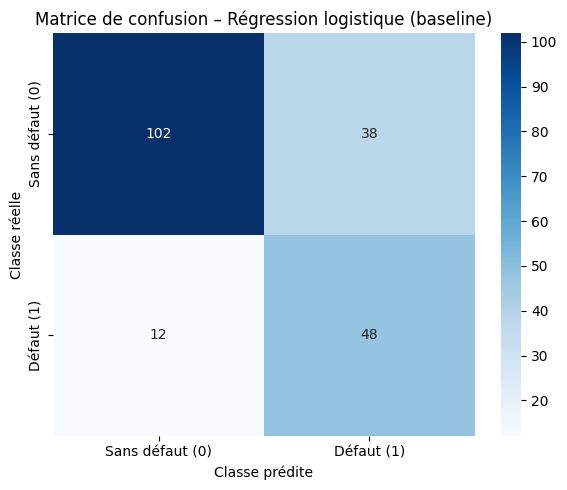

In [46]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# Matrice de confusion (valeurs)
cm = confusion_matrix(y_test, y_pred)

print("Matrice de confusion :")
print(cm)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred, digits=3))

print("ROC-AUC :", roc_auc_score(y_test, y_proba))

# Visualisation de la matrice de confusion
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Sans défaut (0)", "Défaut (1)"],
    yticklabels=["Sans défaut (0)", "Défaut (1)"]
)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion – Régression logistique (baseline)")
plt.tight_layout()
plt.show()



### Modèle baseline : Régression logistique

Un premier modèle de référence a été construit à l’aide d’une **régression logistique**, largement utilisée en scoring crédit pour sa simplicité et son interprétabilité. Le modèle est intégré dans un pipeline comprenant le prétraitement des données (encodage des variables catégorielles et normalisation des variables numériques). Le déséquilibre des classes est pris en compte via une pondération des classes.

Les performances du modèle sont évaluées sur le jeu de test à l’aide de métriques adaptées aux problèmes de classification déséquilibrée, notamment le rappel de la classe défaut et l’aire sous la courbe ROC (ROC-AUC).


In [47]:
import pandas as pd
import numpy as np

# 1) récupérer le modèle entraîné et les noms de features après prétraitement
clf = log_reg_model.named_steps["model"]
feature_names = log_reg_model.named_steps["preprocess"].get_feature_names_out()

# 2) coefficients (une valeur par feature)
coefs = clf.coef_.ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

# Top variables les plus influentes
display(coef_df.head(20))


,feature,coef,abs_coef
3,cat__status_account_A14,-0.987410,0.987410
16,cat__purpose_A46,0.958526,0.958526
10,cat__purpose_A41,-0.887080,0.887080
8,cat__credit_history_A34,-0.852003,0.852003
22,cat__savings_A64,-0.676792,0.676792
53,cat__foreign_worker_A202,-0.651421,0.651421
39,cat__property_A124,0.635350,0.635350
0,cat__status_account_A11,0.620797,0.620797
27,cat__employment_A74,-0.595362,0.595362
4,cat__credit_history_A30,0.589948,0.589948


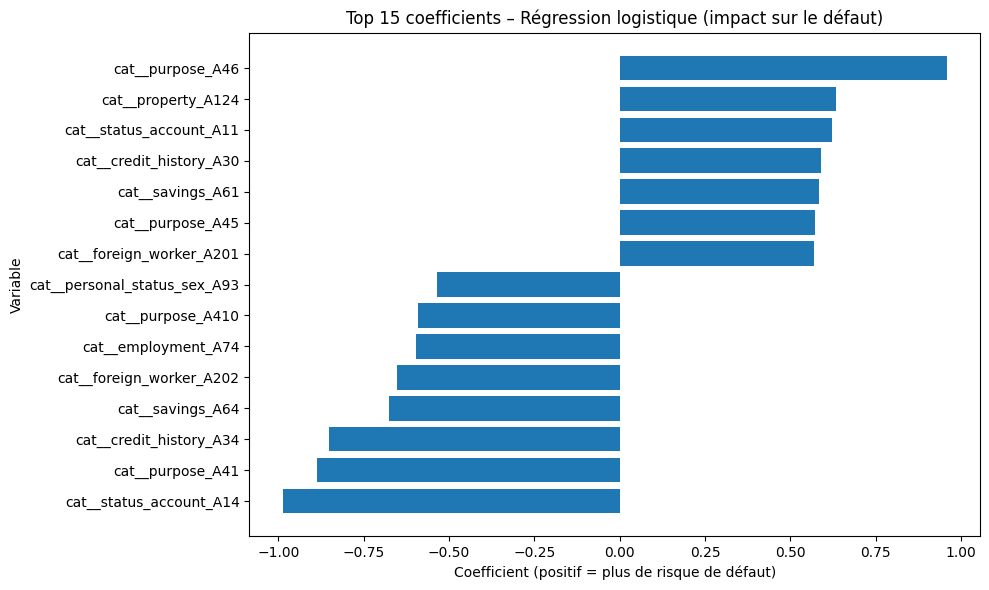

In [48]:
import matplotlib.pyplot as plt

top = coef_df.head(15).sort_values("coef")  # tri pour afficher du négatif au positif

plt.figure(figsize=(10,6))
plt.barh(top["feature"], top["coef"])
plt.title("Top 15 coefficients – Régression logistique (impact sur le défaut)")
plt.xlabel("Coefficient (positif = plus de risque de défaut)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "seuil": t,
        "precision_defaut(1)": precision_score(y_test, y_pred_t, pos_label=1),
        "recall_defaut(1)": recall_score(y_test, y_pred_t, pos_label=1),
        "f1_defaut(1)": f1_score(y_test, y_pred_t, pos_label=1)
    })

th_df = pd.DataFrame(rows)
display(th_df)


,seuil,precision_defaut(1),recall_defaut(1),f1_defaut(1)
0,0.3,0.424000,0.883333,0.572973
1,0.4,0.485437,0.833333,0.613497
2,0.5,0.558140,0.800000,0.657534
3,0.6,0.583333,0.700000,0.636364
4,0.7,0.686275,0.583333,0.630631


In [50]:
from sklearn.metrics import confusion_matrix

t = 0.4  # exemple : seuil plus bas
y_pred_04 = (y_proba >= t).astype(int)

print("Seuil =", t)
print(confusion_matrix(y_test, y_pred_04))


Seuil = 0.4
[[87 53]
 [10 50]]


### Interprétation du modèle et ajustement du seuil

La régression logistique permet d’interpréter l’influence des variables grâce aux **coefficients** : un coefficient positif augmente la probabilité de **défaut**, tandis qu’un coefficient négatif la diminue. Cette interprétabilité est un atout majeur en scoring crédit.

En complément, le **seuil de décision** (0.5 par défaut) peut être ajusté selon l’objectif métier. Dans un contexte bancaire, on cherche souvent à limiter les **faux négatifs** (clients en défaut classés comme bons), ce qui peut conduire à utiliser un seuil plus bas afin de détecter davantage de défauts, au prix d’un nombre plus important de faux positifs.


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),  # même prétraitement
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)


In [52]:
rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

=== RANDOM FOREST ===
Matrice de confusion :
[[112  28]
 [ 18  42]]

Rapport de classification :
              precision    recall  f1-score   support

           0      0.862     0.800     0.830       140
           1      0.600     0.700     0.646        60

    accuracy                          0.770       200
   macro avg      0.731     0.750     0.738       200
weighted avg      0.783     0.770     0.775       200

ROC-AUC : 0.8039285714285714


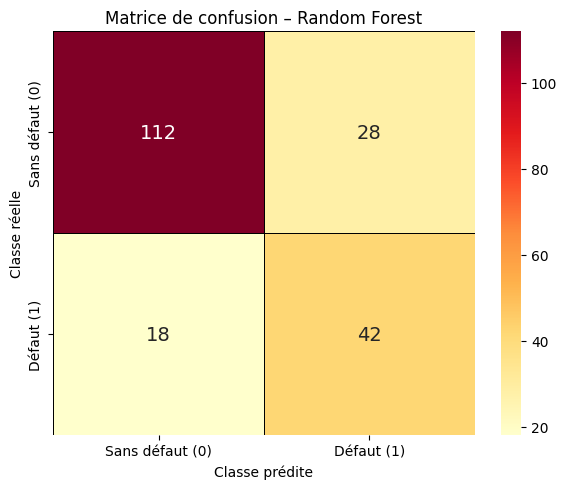

In [57]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Matrice de confusion (valeurs)
cm = confusion_matrix(y_test, y_pred_rf)

print("=== RANDOM FOREST ===")
print("Matrice de confusion :")
print(cm)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_rf, digits=3))

print("ROC-AUC :", roc_auc_score(y_test, y_proba_rf))

# Matrice de confusion (visuel)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="black",
    cbar=True,
    annot_kws={"size": 14},
    xticklabels=["Sans défaut (0)", "Défaut (1)"],
    yticklabels=["Sans défaut (0)", "Défaut (1)"]
)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion – Random Forest")
plt.tight_layout()
plt.show()


In [56]:
results = pd.DataFrame({
    "Modèle": ["Régression logistique", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf)
    ],
    "Recall défaut (1)": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["recall"]
    ],
    "Precision défaut (1)": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_rf, output_dict=True)["1"]["precision"]
    ]
})

results


,Modèle,ROC-AUC,Recall défaut (1),Precision défaut (1)
0,Régression logistique,0.805833,0.8,0.55814
1,Random Forest,0.803929,0.7,0.60000


### Comparaison des modèles et conclusion finale

Afin d’évaluer la robustesse du modèle baseline, une comparaison a été réalisée entre la **régression logistique** et un **Random Forest**, en utilisant les mêmes données d’entraînement et de test ainsi que les mêmes métriques d’évaluation.

Les résultats montrent que les deux modèles présentent des performances globales très proches en termes de pouvoir discriminant, avec un **ROC-AUC de 0,806 pour la régression logistique** et de **0,804 pour le Random Forest**. Cela indique que les deux approches sont capables de distinguer efficacement les clients en défaut des clients solvables.

En ce qui concerne la **détection des clients en défaut**, la régression logistique affiche un **rappel plus élevé pour la classe défaut (80 %)**, contre **70 % pour le Random Forest**. Ce point est particulièrement important dans un contexte de **gestion du risque de crédit**, où les faux négatifs (clients en défaut classés comme bons) représentent un risque financier majeur. La régression logistique permet donc de mieux limiter ce type d’erreur.

À l’inverse, le Random Forest présente une **précision légèrement supérieure sur la classe défaut (60 % contre 55,8 %)**, ce qui signifie qu’il génère moins de fausses alertes. Toutefois, cette amélioration se fait au détriment du rappel, ce qui peut conduire à laisser passer davantage de clients à risque.

D’un point de vue métier, ces résultats illustrent le **compromis classique entre rappel et précision**. Dans un cadre bancaire réglementé, la **régression logistique apparaît comme le modèle le plus adapté**, grâce à son **meilleur rappel sur les défauts**, sa **simplicité** et son **interprétabilité**, éléments essentiels pour l’explicabilité des décisions de crédit. Le Random Forest peut néanmoins être utilisé comme **modèle de comparaison ou de contrôle**, ou dans des contextes moins contraints sur le plan réglementaire.

En conclusion, le modèle de **régression logistique est retenu comme modèle final de scoring crédit**, fournissant un bon équilibre entre performance prédictive, maîtrise du risque et interprétabilité.
